# C1

---

## 1. HISTOGRAM

### Mục đích sử dụng:
- Hiển thị phân phối tần suất của một biến liên tục
- Xác định hình dạng phân phối (normal, skewed, multimodal)
- Tìm range và mode của dữ liệu
- Phát hiện **gaps** hoặc **clusters** trong dữ liệu

### Khi nào sử dụng:
- Dữ liệu: **1 biến liên tục**
- Câu hỏi: "Dữ liệu phân phối như thế nào?"
- Ví dụ: Chiều cao, cân nặng, độ tuổi, điểm số sinh viên

---

## 2. BOX PLOT 

### Mục đích sử dụng:
- Hiển thị **5 con số thống kê**: Min, Q1, Median, Q3, Max
- **So sánh phân phối** giữa các nhóm dữ liệu khác nhau
- Phát hiện **outliers** (giá trị bất thường)
- Kiểm tra **skewness** (độ lệch) của phân phối
- Hiển thị **quartiles** và **interquartile range (IQR)**

### Khi nào sử dụng:
- Dữ liệu: **1 biến liên tục, nhiều nhóm**
- Câu hỏi: "Nhóm nào có phân phối khác nhau? Có outliers không?"
- Ví dụ: So sánh mức lương theo ngành, điểm thi theo lớp, giá nhà theo khu vực

---

## 3. SCATTER PLOT (Biểu đồ phân tán)

### Mục đích sử dụng:
- Hiển thị **mối quan hệ** giữa **2 biến liên tục**
- Phát hiện **tương quan** (correlation) - tuyến tính hay phi tuyến
- Tìm **patterns** và **trends** trong dữ liệu
- Phát hiện **clusters** hoặc **outliers**
- Kiểm tra **linearity** giữa các biến

### Khi nào sử dụng:
- Dữ liệu: **2 biến liên tục** (hoặc 3 nếu dùng màu/kích thước)
- Câu hỏi: "Có mối quan hệ giữa X và Y không?"
- Ví dụ: Mối quan hệ giữa giờ học và điểm số, giữa diện tích nhà và giá bán, giữa tuổi và lương

# C2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r"E:\Visualization\Visualization\Visualization\Data\train.csv")
df.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


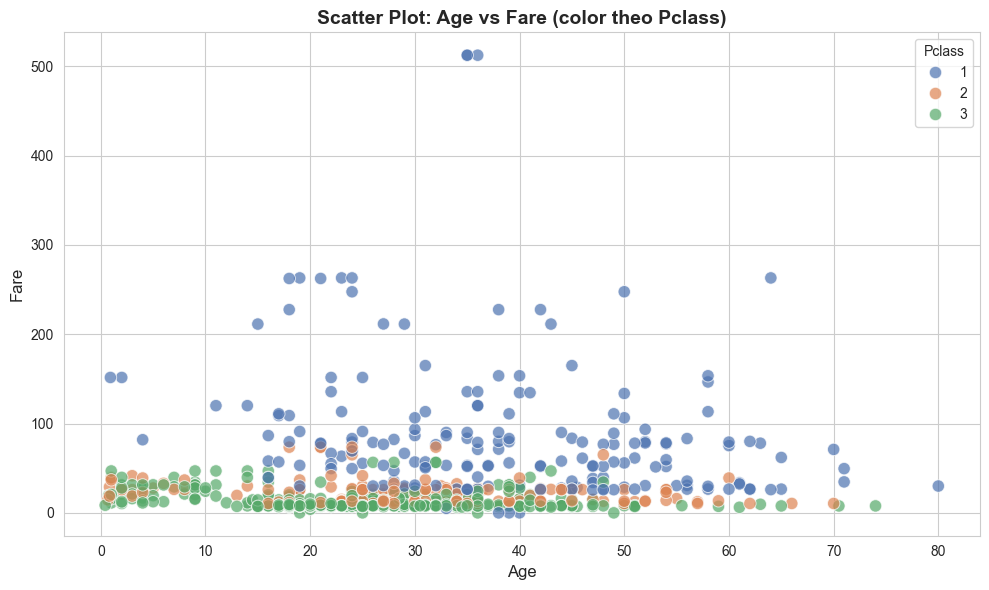

In [7]:


sns.set_style('whitegrid')
plot_df = df.dropna(subset=['Age', 'Fare', 'Pclass']).copy()
plot_df['Pclass'] = plot_df['Pclass'].astype(int)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='Age', y='Fare', hue='Pclass', palette='deep', alpha=0.7, edgecolor='w', s=80)
plt.title('Scatter Plot: Age vs Fare (color theo Pclass)', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.legend(title='Pclass')
plt.tight_layout()
plt.show()

-  Xu hướng chung: hành khách trẻ hơn thường trả giá vé thấp hơn

- Pclass 1 : Fare cao hơn Pclass2+3, có outliers (hơn 500 )

- Pclass 3 có nhiều điểm dữ liệu ở phí vé thấp

- Scatter Plot phù hợp :  thể hiện mối quan hệ giữa hai biến liên tục Age và Fare và cho thấy sự phân tách theo Pclass.'

- Histogram chỉ cho phân phối của Age hoặc Fare riêng rẽ, không cho thấy tương quan giữa hai biến

- Box Plot so sánh nhóm theo Pclass tốt với một biến liên tục, nhưng không trực quan bằng Scatter Plot cho mối quan hệ Age vs Fare.

# C3 :Xác định 3 thuộc tính có ảnh hưởng nhiều nhất đến khả năng sống sót của hành khách

In [13]:
analysis_df = df.copy()
analysis_df['Sex_n'] = analysis_df['Sex'].map({'male': 0, 'female': 1})
analysis_df['Embarked_n'] = analysis_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [11]:
corr = analysis_df[['Survived', 'Pclass', 'Sex_n', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_n']].corr()['Survived'].abs().sort_values(ascending=False)
print('Độ tương quan tuyệt đối với Survived:')
print(corr)

print(' 3 thuộc tính dựa trên tương quan tuyệt đối:')
print(corr.index[1:4].tolist())

print('\nTỷ lệ sống sót theo Pclass:')
print(df.groupby('Pclass')['Survived'].mean())

print('\nTỷ lệ sống sót theo Sex:')
print(df.groupby('Sex')['Survived'].mean())

age_bins = [0, 12, 18, 30, 50, 80]
df['AgeGroup'] = pd.cut(df['Age'], age_bins)
print('\nTỷ lệ sống sót theo nhóm tuổi:')
print(df.groupby('AgeGroup')['Survived'].mean())

Độ tương quan tuyệt đối với Survived:
Survived      1.000000
Sex_n         0.543351
Pclass        0.338481
Fare          0.257307
Embarked_n    0.108669
Parch         0.081629
Age           0.077221
SibSp         0.035322
Name: Survived, dtype: float64
 3 thuộc tính dựa trên tương quan tuyệt đối:
['Sex_n', 'Pclass', 'Fare']

Tỷ lệ sống sót theo Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Tỷ lệ sống sót theo Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Tỷ lệ sống sót theo nhóm tuổi:
AgeGroup
(0, 12]     0.579710
(12, 18]    0.428571
(18, 30]    0.355556
(30, 50]    0.423237
(50, 80]    0.343750
Name: Survived, dtype: float64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16644\1186592471.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['Survived'].mean())


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16644\4278135016.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Age', palette=["#e74c3c", '#e7f0e9'], ax=ax3, width=0.5)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16644\4278135016.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['Chết (0)', 'Sống (1)'], fontsize=10)


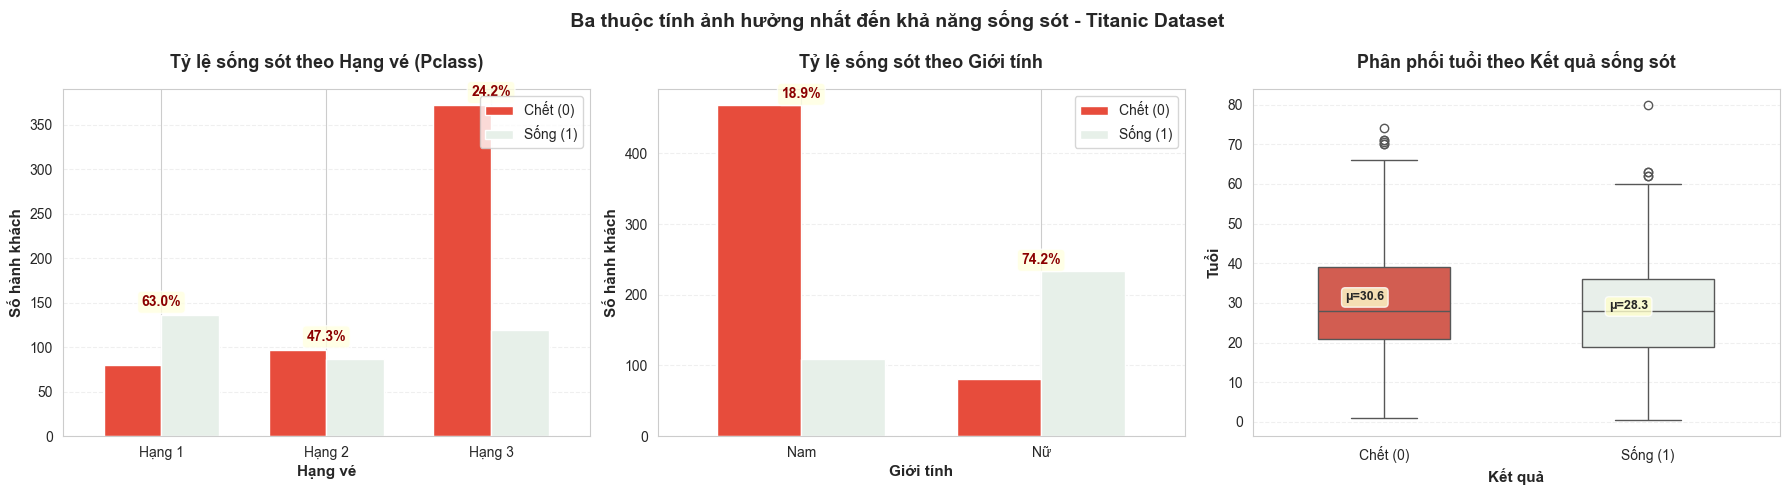


 PCLASS (Hạng vé) - Xanh=Chết, Cam=Sống:
   Hạng 1: Chết=80, Sống=136, Tổng=216, % sống=63.0%
   Hạng 2: Chết=97, Sống=87, Tổng=184, % sống=47.3%
   Hạng 3: Chết=372, Sống=119, Tổng=491, % sống=24.2%

 SEX (Giới tính) - Xanh=Chết, Cam=Sống:
   Nam: Chết=468, Sống=109, Tổng=577, % sống=18.9%
   Nữ: Chết=81, Sống=233, Tổng=314, % sống=74.2%

 AGE (Tuổi):
   CHẾT: Trung bình=30.6 tuổi, Median=28 tuổi
   SỐNG: Trung bình=28.3 tuổi, Median=28 tuổi


In [ ]:
fig = plt.figure(figsize=(18, 5))

#  PLOT 1: PCLASS vs SURVIVED 
ax1 = plt.subplot(1, 3, 1)
pclass_data = pd.crosstab(df['Pclass'], df['Survived'])
pclass_data.plot(kind='bar', ax=ax1, width=0.7, color=['#e74c3c', '#e7f0e9'])  # Xanh, cam
ax1.set_title('Tỷ lệ sống sót theo Hạng vé (Pclass)', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Hạng vé', fontsize=11, fontweight='bold')
ax1.set_ylabel('Số hành khách', fontsize=11, fontweight='bold')
ax1.set_xticklabels(['Hạng 1', 'Hạng 2', 'Hạng 3'], rotation=0, fontsize=10)
ax1.legend(['Chết (0)', 'Sống (1)'], fontsize=10, loc='upper right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for i, pclass in enumerate([1, 2, 3]):
    survived = len(df[(df['Pclass'] == pclass) & (df['Survived'] == 1)])
    total = len(df[df['Pclass'] == pclass])
    pct = (survived / total) * 100
    max_y = pclass_data.loc[pclass].max()
    ax1.text(i, max_y + 10, f'{pct:.1f}%', ha='center', fontsize=10, 
            fontweight='bold', color='darkred', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

#  PLOT 2: SEX vs SURVIVED 
ax2 = plt.subplot(1, 3, 2)
sex_map = {'male': 'Nam', 'female': 'Nữ'}
sex_data_dict = {}
for sex_val in ['male', 'female']:
    sex_data_dict[sex_map[sex_val]] = [
        len(df[(df['Sex'] == sex_val) & (df['Survived'] == 0)]),
        len(df[(df['Sex'] == sex_val) & (df['Survived'] == 1)])
    ]
sex_data = pd.DataFrame(sex_data_dict).T
sex_data.columns = ['Chết (0)', 'Sống (1)']
sex_data.plot(kind='bar', ax=ax2, width=0.7, color=['#e74c3c', '#e7f0e9'])  # Xanh, cam
ax2.set_title('Tỷ lệ sống sót theo Giới tính', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Giới tính', fontsize=11, fontweight='bold')
ax2.set_ylabel('Số hành khách', fontsize=11, fontweight='bold')
ax2.set_xticklabels(['Nam', 'Nữ'], rotation=0, fontsize=10)
ax2.legend(['Chết (0)', 'Sống (1)'], fontsize=10, loc='upper right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for i, sex_val in enumerate(['male', 'female']):
    survived = len(df[(df['Sex'] == sex_val) & (df['Survived'] == 1)])
    total = len(df[df['Sex'] == sex_val])
    pct = (survived / total) * 100
    max_y = sex_data.loc[sex_map[sex_val]].max()
    ax2.text(i, max_y + 10, f'{pct:.1f}%', ha='center', fontsize=10, 
            fontweight='bold', color='darkred', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

#  PLOT 3: AGE vs SURVIVED 
ax3 = plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Survived', y='Age', palette=["#e74c3c", '#e7f0e9'], ax=ax3, width=0.5)
ax3.set_title('Phân phối tuổi theo Kết quả sống sót', fontsize=13, fontweight='bold', pad=15)
ax3.set_xlabel('Kết quả', fontsize=11, fontweight='bold')
ax3.set_ylabel('Tuổi', fontsize=11, fontweight='bold')
ax3.set_xticklabels(['Chết (0)', 'Sống (1)'], fontsize=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm chú thích tuổi trung bình
for i, survived in enumerate([0, 1]):
    mean_age = df[df['Survived'] == survived]['Age'].mean()
    median_age = df[df['Survived'] == survived]['Age'].median()
    ax3.text(i, mean_age, f'μ={mean_age:.1f}', ha='right', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#ffffcc', alpha=0.8))

plt.suptitle(' Ba thuộc tính ảnh hưởng nhất đến khả năng sống sót - Titanic Dataset', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n PCLASS (Hạng vé) - Xanh=Chết, Cam=Sống:")
for pclass in [1, 2, 3]:
    died = len(df[(df['Pclass'] == pclass) & (df['Survived'] == 0)])
    alive = len(df[(df['Pclass'] == pclass) & (df['Survived'] == 1)])
    total = died + alive
    pct_alive = (alive / total) * 100
    print(f"   Hạng {pclass}: Chết={died}, Sống={alive}, Tổng={total}, % sống={pct_alive:.1f}%")

print("\n SEX (Giới tính) - Xanh=Chết, Cam=Sống:")
for sex in ['male', 'female']:
    died = len(df[(df['Sex'] == sex) & (df['Survived'] == 0)])
    alive = len(df[(df['Sex'] == sex) & (df['Survived'] == 1)])
    total = died + alive
    pct_alive = (alive / total) * 100
    sex_label = "Nam" if sex == "male" else "Nữ"
    print(f"   {sex_label}: Chết={died}, Sống={alive}, Tổng={total}, % sống={pct_alive:.1f}%")

print("\n AGE (Tuổi):")
for survived in [0, 1]:
    label = "CHẾT" if survived == 0 else "SỐNG"
    age_stats = df[df['Survived'] == survived]['Age']
    print(f"   {label}: Trung bình={age_stats.mean():.1f} tuổi, Median={age_stats.median():.0f} tuổi")


- Pclass (Hạng vé) :
    - 

## Kết luận: 3 thuộc tính ảnh hưởng nhất đến Survived

- **Sex**: Nữ có tỷ lệ sống sót cao hơn nam
- **Pclass**: Hạng vé là chỉ số mạnh của vị trí trên tàu và khả năng tiếp cận phương tiện cứu hộ.
- **Age**: Trẻ em thường được ưu tiên cứu hộ, nên nhóm tuổi cũng ảnh hưởng rõ.


## 7. PCA vs t-SNE: Giảm dữ liệu nhiều chiều xuống 2D

### PCA (Principal Component Analysis)

**Ưu điểm:**
-  Nhanh, dễ tính toán
-  Kết quả dễ giải thích vì mỗi thành phần là tổ hợp tuyến tính của các biến gốc
-  Tốt khi dữ liệu có cấu trúc **tuyến tính**
-  Bảo toàn cấu trúc **toàn cục**

**Hạn chế:**
-  Chỉ bắt được mối quan hệ **tuyến tính**
-  Không tốt nếu dữ liệu có cấu trúc **phi tuyến**
-  Có thể mất thông tin khi giảm xuống 2 chiều nếu dữ liệu cao chiều phức tạp

**Trường hợp sử dụng:**
- Giảm chiều để tiền xử lý cho mô hình học máy
- Cần giữ cấu trúc tổng thể và giải thích được thành phần chính
- Dữ liệu kích thước lớn, cần tốc độ nhanh

---

### t-SNE (t-distributed Stochastic Neighbor Embedding)



**Ưu điểm:**
-  Hiệu quả trong việc **khám phá cụm** (clusters)
-  Xử lý tốt cấu trúc **phi tuyến**
-  Thường cho hình ảnh **rõ ràng** về phân tách cụm
-  Bảo toàn cấu trúc **cục bộ** (local structure)

**Hạn chế:**
-  **Chậm**, tính toán tốn thời gian với dữ liệu lớn
-  Kết quả **không ổn định** giữa các lần chạy (cần cố định random state)
-  Không dễ giải thích vì không có ánh xạ tuyến tính rõ ràng trở lại biến gốc
-  Khoảng cách tuyệt đối trong không gian 2D **không mang ý nghĩa** như trong dữ liệu gốc

**Trường hợp sử dụng:**
- Trực quan hóa phân cụm, khám phá dữ liệu
- Dữ liệu với cấu trúc **phi tuyến phức tạp**
- Kiểm tra cấu trúc cục bộ, cluster hoặc phân biệt lớp
- Kích thước dữ liệu vừa phải, mục tiêu là **hình ảnh trực quan**

---

### So sánh tóm tắt

| Tiêu chí | PCA | t-SNE |
|----------|-----|-------|
| **Tốc độ** | Nhanh  | Chậm  |
| **Cấu trúc dữ liệu** | Tuyến tính | Phi tuyến |
| **Bảo toàn** | Cấu trúc toàn cục | Cấu trúc cục bộ |
| **Dễ giải thích** | Có  | Khó  |
| **Ứng dụng chính** | Tiền xử lý ML | Trực quan khám phá |
| **Dữ liệu lớn** | Tốt | Không tốt |

---

### Khi nào dùng 

- **PCA** nếu muốn: trực quan hóa nhanh, giữ cấu trúc toàn cục, giải thích dễ
- **t-SNE** nếu muốn: kiểm tra phân cụm, phát hiện cấu trúc phi tuyến, trực quan chi tiết